<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB39b · Muelles, amortiguadores y ecuaciones diferenciales

**Parte 5 · La física del cuerpo — Lección intermedia (entre el NB39 y el NB40)**

> Los **muelles** están por todas partes en un robot, aunque no los veas. En el NB38 convertiste las articulaciones de Hopper en muelles para que se sostuviera como una estatua. En el NB40 descubrirás que el controlador más usado de la robótica, el **PD**, es un muelle con un amortiguador. En el NB48 verás que MuJoCo calcula los **choques** con muelles. Y en el NB49, que una simulación **explota** cuando un muelle es demasiado duro para su pasito.

Hoy estudiamos el muelle a fondo, con tres preguntas:

1. ¿**Cómo** oscila un muelle, y **a qué ritmo**? (Una letra: **ω**.)
2. ¿Cómo se **calma** una oscilación, y cuál es la forma **justa** de calmarla? (Otra letra: **ζ**.)
3. ¿Por qué, a veces, al simular un muelle con el ordenador, **explota**? (Una regla: **pasito × ω < 2**.)

Por el camino aprenderás qué es una **ecuación diferencial**, el tipo de ecuación con el que está escrita toda la física (y todo simulador), y las pendientes del **seno** y del **coseno**, que nos faltaban del NB17b.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## 1 · El muelle: la ley de Hooke

Estira un muelle: tira para volver. Estíralo el doble: tira el doble. Comprímelo: empuja para volver. Esto lo descubrió el inglés Robert Hooke en 1660, y se escribe:

```
   fuerza del muelle  =  − k × x
```

- **x** es cuánto está estirado (positivo) o comprimido (negativo) respecto de su largo natural, en metros.
- **k** es la **rigidez** del muelle, en newtons por metro (N/m): cuántos newtons hace por cada metro que lo estiras. Un muelle de bolígrafo, unos 100 N/m; el de la suspensión de un coche, unos 30.000 N/m.
- El **signo menos** es lo importante: la fuerza va siempre **en contra** del estiramiento. Si x es positivo, empuja hacia los negativos, y al revés. Siempre hacia el **centro**.

Cuelga una masa m del muelle (o ponla en una mesa sin rozamiento, atada a una pared). Por Newton (NB37), su aceleración es la fuerza entre la masa:

```
   aceleración  =  − (k / m) × x
```

Simulémoslo con la cadena de oro del NB07 (aceleración → velocidad → posición): una masa de 1 kg, un muelle de 100 N/m, estirado 0,1 m y soltado:


In [2]:
def simular_muelle(k, m, c=0.0, x0=0.1, duracion=2.0, paso=0.0001):
    x, v = x0, 0.0
    tiempos, posiciones = [], []
    for i in range(round(duracion / paso)):
        aceleracion = (-k * x - c * v) / m       # muelle (y amortiguador, que de momento es 0)
        v = v + aceleracion * paso
        x = x + v * paso
        tiempos.append((i + 1) * paso)
        posiciones.append(x)
    return np.array(tiempos), np.array(posiciones)

(La función ya tiene preparado un hueco para el **amortiguador**, `c`, que veremos en el apartado 5; con c = 0 no hace nada.)

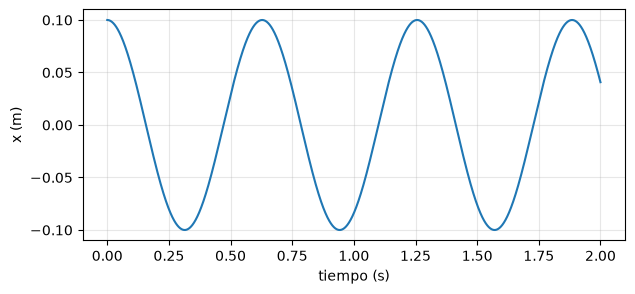

In [3]:
t, x = simular_muelle(k=100, m=1)
plt.figure(figsize=(7, 3))
plt.plot(t, x)
plt.xlabel("tiempo (s)")
plt.ylabel("x (m)")
plt.grid(alpha=0.3)
plt.show()

Una **oscilación** perfecta: va y viene, de +0,1 a −0,1 y vuelta, para siempre (sin rozamiento, nada la frena). Y parece una onda conocida... la del **coseno** del NB36. Vamos a demostrar que **es** un coseno, y a calcular su ritmo sin simular. Para eso necesitamos dos herramientas nuevas.


## 2 · Las ecuaciones diferenciales

Mira otra vez la regla del muelle: "la aceleración es −(k/m) por la posición". La aceleración es la **pendiente de la velocidad**, y la velocidad, la **pendiente de la posición** (NB16): es decir, la aceleración es la **segunda derivada** de la posición (NB17b). Con la notación del NB17b, x'' (se lee "x dos primas"):

```
   x''  =  − (k / m) · x
```

Esto es una ecuación rara. En el NB04b, la incógnita de una ecuación era un **número** (2·x + 1 = 7 → x = 3). Aquí la incógnita es una **función entera**, x(t), la posición en cada instante. La ecuación no dice cuánto vale x, sino **una relación entre x y sus pendientes** que tiene que cumplirse en todo momento. A esto se le llama **ecuación diferencial**.

Las conoces sin saberlo:

- La caída libre (NB04b): **h'' = −g**. "La aceleración de la altura es siempre −g". Su solución es h(t) = h₀ − ½·g·t².
- El palo de escoba (NB37): **θ'' = (3g / 2L)·sin θ**.
- El péndulo invertido lineal (NB39): **x'' = ω²·(x − p)**.

**Toda** la física de un robot es una gran ecuación diferencial (NB45: M·q̈ + ... = τ). Y un **simulador** es, exactamente, una máquina de resolver ecuaciones diferenciales **a pasitos**: lo que hace la cadena de oro del NB07, y lo que hace `mj_step`.

Algunas, pocas, se pueden resolver con lápiz: encontrar una fórmula para la función. La del muelle es una de ellas. Para eso, necesitamos las pendientes del seno y del coseno.


## 3 · Las pendientes del seno y del coseno

### La intuición: el punto que gira

En el NB36, el seno y el coseno eran las **sombras** de un punto que gira en un círculo de radio 1: la sombra horizontal es cos(t), y la vertical, sin(t), donde t es el ángulo girado (en radianes). Si el punto gira a 1 radián por segundo, t es también el tiempo.

¿Hacia dónde se mueve el punto? Siempre **perpendicular al radio**, tangente al círculo, a velocidad 1 (recorre 1 radián, que en un círculo de radio 1 es un arco de largo 1, cada segundo). Mira el punto en dos momentos:

- En **t = 0** está a la derecha, en (1, 0). Se mueve **hacia arriba**, a toda velocidad. La sombra vertical (sin) sube a ritmo 1, y cos(0) = 1. La horizontal (cos) no se mueve (ritmo 0), y sin(0) = 0.
- En **t = π/2** está arriba, en (0, 1). Se mueve **hacia la izquierda**. La sombra vertical está quieta en su máximo (ritmo 0 = cos(π/2)), y la horizontal baja a ritmo −1 = −sin(π/2).

En **cualquier** momento pasa lo mismo, y queda:

```
   la pendiente de sin(t) es  cos(t)
   la pendiente de cos(t) es  − sin(t)
```

Comprobémoslo con la pendiente numérica del NB16, en varios puntos:


In [4]:
def pendiente(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

for punto in [0.0, 0.7, 2.0, 4.0]:
    print(f"t = {punto}: pend. de sin {pendiente(math.sin, punto):+.5f} | cos {math.cos(punto):+.5f}"
          f"   ||   pend. de cos {pendiente(math.cos, punto):+.5f} | −sin {-math.sin(punto):+.5f}")

t = 0.0: pend. de sin +1.00000 | cos +1.00000   ||   pend. de cos +0.00000 | −sin -0.00000
t = 0.7: pend. de sin +0.76484 | cos +0.76484   ||   pend. de cos -0.64422 | −sin -0.64422
t = 2.0: pend. de sin -0.41615 | cos -0.41615   ||   pend. de cos -0.90930 | −sin -0.90930
t = 4.0: pend. de sin -0.65364 | cos -0.65364   ||   pend. de cos +0.75680 | −sin +0.75680


Las columnas coinciden: ✓.

### Con la regla de la cadena

Si el punto gira **ω veces más deprisa** (ω radianes por segundo), el ángulo es ω·t. Por la regla de la cadena (NB17b, "la pendiente de lo de dentro"), la pendiente de lo de dentro, ω·t, es ω:

```
   la pendiente de cos(ω·t) es  − ω · sin(ω·t)
   y la pendiente de ESO (la segunda derivada) es  − ω · ω · cos(ω·t)  =  − ω² · cos(ω·t)
```

¡Mira la última línea! La segunda derivada de cos(ω·t) es **−ω² por el propio cos(ω·t)**. Es **exactamente** la forma de la ecuación del muelle, x'' = −(k/m)·x, si ω² = k/m.


## 4 · La solución del muelle: ω

Así que la función

```
   x(t)  =  A · cos(ω · t)          con     ω  =  √(k / m)
```

cumple la ecuación del muelle (multiplicar por A no estropea nada: constante por función, NB17b). Y empieza bien: en t = 0, cos(0) = 1, así que x(0) = A, la posición inicial; y la velocidad, −A·ω·sin(0) = 0: parada. Es la solución de nuestro experimento con A = 0,1.

**ω** (omega) es la **frecuencia angular**: cuántos radianes "gira" la oscilación cada segundo. Su unidad es rad/s (o simplemente 1/s). Comparemos la fórmula con la simulación:


In [5]:
k, m, A = 100, 1, 0.1
omega = math.sqrt(k / m)
formula = A * np.cos(omega * t)
print(f"ω = {omega} rad/s")
print("mayor diferencia entre simulación y fórmula:", np.max(np.abs(x - formula)).round(6), "m")

ω = 10.0 rad/s
mayor diferencia entre simulación y fórmula: 5e-05 m


Una diferencia de micras en dos segundos (el error de los pasitos). La simulación **era** un coseno.

### Periodo y frecuencia

Una oscilación completa (ida y vuelta) es una vuelta entera del punto: 2π radianes. A ω radianes por segundo, tarda:

```
   periodo  T  =  2π / ω               (segundos por oscilación)
   frecuencia  f  =  1 / T  =  ω / 2π   (oscilaciones por segundo: hercios, Hz)
```


In [6]:
print(f"periodo: {2 * math.pi / omega:.3f} s | frecuencia: {omega / (2 * math.pi):.2f} Hz")

periodo: 0.628 s | frecuencia: 1.59 Hz


Unas 1,6 oscilaciones por segundo: en la gráfica, en 2 s hay algo más de 3 ondas ✓.

### Lo que dice ω = √(k/m)

- **Muelle más duro** (k grande) → ω mayor → oscila **más deprisa**. Un muelle 4 veces más duro, el doble de rápido (por la raíz).
- **Más masa** (m grande) → ω menor → oscila **más despacio**. Un coche cargado bota más lento que uno vacío.
- La **amplitud** A no aparece en ω: oscile mucho o poco, el ritmo es el mismo. (Galileo lo descubrió con un péndulo en la catedral de Pisa: por eso los péndulos sirvieron para hacer relojes.)

Para **giros** es igual, cambiando masa por **inercia de giro** I (NB37) y la rigidez k por una rigidez de giro (N·m por radián): **ω = √(k / I)**. Es la fórmula que usarás en el NB49.


### El signo lo decide todo

Compara la ecuación del muelle con la del péndulo invertido lineal del NB39:

```
   muelle:              x''  =  − ω² · x          (la fuerza devuelve hacia el centro)
   péndulo invertido:   x''  =  + ω² · x          (la fuerza aleja del centro, con p = 0)
```

¡Solo cambia el **signo**! Y con él, todo: el muelle **oscila** para siempre alrededor del centro; el péndulo invertido **se cae** cada vez más deprisa. ¿Qué función tiene como segunda derivada **+ω²** por ella misma? La exponencial (NB17b): la pendiente de e^(ω·t) es ω·e^(ω·t), y la de eso, ω²·e^(ω·t). La solución del péndulo invertido crece como **e^(ω·t)**, el crecimiento exponencial del NB15b: por eso una caída empieza imperceptible y acaba en el suelo de golpe (lo viste con el palo de escoba en el NB37).

Una sola regla para toda la Parte 5: **fuerza hacia el centro → oscila (estable); fuerza hacia fuera → crece exponencialmente (inestable)**. El trabajo de un controlador (NB40) es, en el fondo, convertir el segundo caso en el primero.


### La energía del muelle

En el NB38b viste la energía de la altura (m·g·h). Un muelle estirado también guarda energía: la **energía elástica**,

```
   energía del muelle  =  ½ · k · x²
```

(El trabajo de estirarlo: la fuerza crece de 0 a k·x mientras lo estiras x, así que la fuerza media es ½·k·x, y por x metros, ½·k·x².) En la oscilación, la energía pasa de elástica (en los extremos, quieto y estirado) a cinética (en el centro, sin estirar y a toda velocidad) y vuelve, sin perderse:


In [7]:
v = np.gradient(x, t)                                  # la velocidad, como pendiente de x (NB16)
energia = 0.5 * m * v ** 2 + 0.5 * k * x ** 2
print(f"energía total: mínima {energia[10:-10].min():.4f} J | máxima {energia[10:-10].max():.4f} J")

energía total: mínima 0.5000 J | máxima 0.5000 J


(`np.gradient(x, t)` calcula la pendiente numérica de una lista de valores en cada punto, como nuestra función `pendiente` pero de golpe para todo el array. Quitamos 10 puntos de cada extremo, donde es menos precisa.)

Se queda en **0,5 J** = ½ × 100 × 0,1²: la energía elástica del principio. ✓


## 5 · El amortiguador: calmar la oscilación

### La fuerza del amortiguador

Un **amortiguador** hace una fuerza que va **en contra de la velocidad**, tanto más fuerte cuanto más deprisa te mueves:

```
   fuerza del amortiguador  =  − c × v
```

**c** es el coeficiente de amortiguamiento (N por cada m/s). Es como mover la mano en el agua: despacio, apenas frena; deprisa, mucho. Los amortiguadores de los coches son cilindros de aceite que hacen justo eso. Y como frenan, **disipan** energía (NB38b): la convierten en calor.

Con muelle y amortiguador, la ecuación es:

```
   m · x''  =  − k · x  −  c · x'
```

Probemos con el muelle de antes y varios amortiguadores:


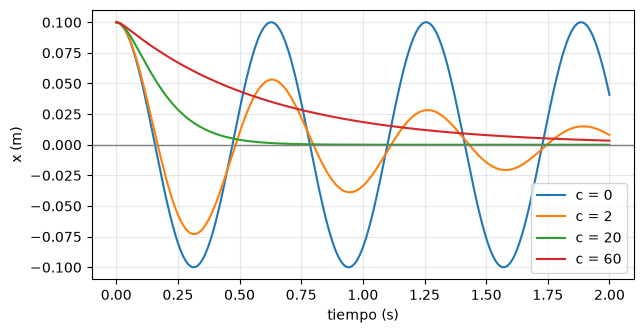

In [8]:
plt.figure(figsize=(7, 3.5))
for c in [0, 2, 20, 60]:
    t, x = simular_muelle(k=100, m=1, c=c)
    plt.plot(t, x, label=f"c = {c}")
plt.axhline(0, color="gray", lw=1)
plt.xlabel("tiempo (s)")
plt.ylabel("x (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Cuatro comportamientos:

- **c = 0**: oscila para siempre.
- **c = 2**: oscila, pero cada vez menos. Se va calmando poco a poco.
- **c = 20**: vuelve al centro **sin pasarse**, y rapidísimo.
- **c = 60**: vuelve sin pasarse, pero **más despacio**: el amortiguador es tan fuerte que frena hasta la vuelta.

¿Dónde está la frontera entre "se pasa" y "no se pasa"? Parece que en c = 20 justo. ¿Casualidad?

### El amortiguamiento crítico y ζ

No. Con lápiz se puede demostrar (es una cuenta más larga, la verás en cualquier libro de "vibraciones") que la frontera está exactamente en:

```
   c crítico  =  2 · √(k · m)
```

Con k = 100 y m = 1: 2 × √100 = **20**. ✓. Y para comparar cualquier amortiguador con su crítico, se usa un único número, el **coeficiente de amortiguamiento** ζ (la letra griega *zeta*):

```
   ζ  =  c / c crítico  =  c / (2 · √(k · m))
```

| ζ | Nombre | Qué hace |
|---|---|---|
| ζ = 0 | sin amortiguar | oscila para siempre |
| 0 < ζ < 1 | **subamortiguado** | oscila, cada vez menos |
| ζ = 1 | **crítico** | vuelve lo más rápido posible **sin pasarse** |
| ζ > 1 | **sobreamortiguado** | vuelve sin pasarse, pero lento |

Nuestras curvas eran ζ = 0, 0,1, 1 y 3. Lo bonito de ζ es que **no tiene unidades** y no depende del tamaño: un muelle de juguete y la suspensión de un camión con el mismo ζ se comportan "igual", cada uno a su ritmo ω. Por eso los ingenieros (y MuJoCo, en el NB48: `dampratio`) describen los amortiguadores con ζ en vez de con c.


### Cuánto se pasa

En la práctica, muchas veces se elige un ζ algo **menor** que 1 (0,6 o 0,7): se pasa un poquito del objetivo, pero llega antes. ¿Cuánto se pasa? Midámoslo: el valor más negativo de x (el rebote hacia el otro lado), en porcentaje de los 0,1 m del principio:


In [9]:
for zeta in [0.1, 0.3, 0.5, 0.7, 1.0]:
    c = zeta * 2 * math.sqrt(100 * 1)
    t, x = simular_muelle(k=100, m=1, c=c)
    print(f"ζ = {zeta}: se pasa un {100 * max(0, -x.min()) / 0.1:4.1f} %")

ζ = 0.1: se pasa un 72.9 %
ζ = 0.3: se pasa un 37.2 %
ζ = 0.5: se pasa un 16.3 %
ζ = 0.7: se pasa un  4.6 %
ζ = 1.0: se pasa un  0.0 %


Con ζ = 0,1, rebota un 73 % al otro lado; con 0,7, apenas un 5 %; con 1, nada. Un ζ de 0,7 es una elección clásica: se pasa muy poco y llega antes que el crítico al entorno del objetivo.

### La envolvente: e^(−ζ·ω·t)

En el caso subamortiguado, los picos de la oscilación van bajando siguiendo una curva: el **decaimiento exponencial** del NB15b:

```
   altura de los picos  ≈  A · e^(− ζ · ω · t)
```

(Para ζ pequeño; es otra cuenta de libro.) Su **constante de tiempo** (NB15b: cuando queda el 37 %) es 1/(ζ·ω). Dibujemos la de ζ = 0,1:


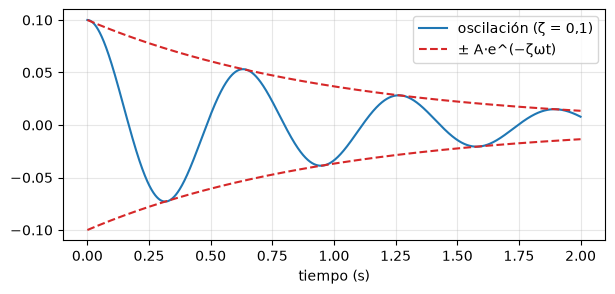

In [10]:
zeta = 0.1
t, x = simular_muelle(k=100, m=1, c=zeta * 20)
envolvente = 0.1 * np.exp(-zeta * 10 * t)              # ω = 10
plt.figure(figsize=(7, 3))
plt.plot(t, x, label="oscilación (ζ = 0,1)")
plt.plot(t, envolvente, "--", color="tab:red", label="± A·e^(−ζωt)")
plt.plot(t, -envolvente, "--", color="tab:red")
plt.xlabel("tiempo (s)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Los picos se apoyan en la curva roja. La constante de tiempo es 1/(0,1 × 10) = **1 s**: al segundo, la oscilación ha bajado al 37 %.


## 6 · El controlador PD es un muelle con amortiguador

En el NB40 construirás el controlador **PD**: el motor de una articulación hace un par

```
   par  =  Kp × (objetivo − ángulo)  −  Kd × velocidad de giro
```

Es **exactamente** un muelle de rigidez **Kp** que une la articulación con el ángulo objetivo, más un amortiguador de coeficiente **Kd**. Así que todo lo de hoy vale para él, cambiando la masa por la inercia de giro I:

- ω = √(Kp / I): lo **rápido** que responde la articulación.
- ζ = Kd / (2·√(Kp · I)): si **rebota** o no.
- El amortiguamiento crítico: **Kd = 2·√(Kp · I)**. Una regla muy usada para elegir Kd a partir de Kp.

Un adelanto del NB40: allí la pierna tiene I ≈ 0,167 kg·m² y Kp = 50, y probarás Kd = 1, 3 y 10. Calcula sus ζ:


In [11]:
I_pierna, Kp = 2.0 * 0.5 ** 2 / 3, 50
for Kd in [1, 3, 10]:
    print(f"Kd = {Kd:>2}: ζ = {Kd / (2 * math.sqrt(Kp * I_pierna)):.2f}")
print(f"Kd crítico: {2 * math.sqrt(Kp * I_pierna):.2f}")

Kd =  1: ζ = 0.17
Kd =  3: ζ = 0.52
Kd = 10: ζ = 1.73
Kd crítico: 5.77


Cuando lo veas en el NB40, comprueba si casa: con ζ = 0,17, rebotes; con 0,52, se pasa un poco y se para; con 1,73, sin pasarse pero lento. (La gravedad también actúa como un pequeño muelle extra, así que los números no serán exactos.) Saber esto convierte el ajuste de un PD de "probar números a ciegas" en una **cuenta**.


## 7 · Cuando la simulación explota: la estabilidad

### El caso más sencillo

Antes de los muelles, una ecuación diferencial aún más sencilla, de **primer** orden (solo una pendiente):

```
   x'  =  − λ · x                (λ, "lambda", un número positivo)
```

"Cuanto más grande es x, más deprisa baja". Es el **decaimiento exponencial** del NB15b: la solución exacta es x(t) = x₀·e^(−λ·t), que baja suavemente hacia 0. Describe muchas cosas: un café que se enfría, un amortiguador sin masa... o la velocidad de una articulación frenada por un `kv` (lo verás en el NB49).

Resolvámosla con Euler (NB07), con un pasito h. En cada pasito:

```
   x_nuevo  =  x  +  h · (−λ · x)  =  (1 − h·λ) · x
```

**¡Cada pasito multiplica x por el mismo número, (1 − h·λ)!** Y ahora piensa qué pasa al multiplicar muchas veces por un número (NB03b):

- Si el número está entre 0 y 1 (h·λ < 1): x baja poco a poco, hacia 0. **Bien**.
- Si está entre −1 y 0 (h·λ entre 1 y 2): x cambia de signo en cada pasito (+, −, +, −), pero cada vez más pequeño. **Raro, pero llega a 0**.
- Si es menor que −1 (h·λ > 2): x cambia de signo **y crece** cada vez: **explota**.

La solución de verdad siempre baja a 0, pero la de Euler explota si **h·λ > 2**. Probémoslo con λ = 10 (constante de tiempo 0,1 s):


In [12]:
lam = 10
for h in [0.05, 0.15, 0.25]:
    x, valores = 1.0, []
    for i in range(8):
        x = x + h * (-lam * x)
        valores.append(round(x, 3))
    print(f"h·λ = {h * lam:.1f}  (factor {1 - h * lam:+.1f}): {valores}")

h·λ = 0.5  (factor +0.5): [0.5, 0.25, 0.125, 0.062, 0.031, 0.016, 0.008, 0.004]
h·λ = 1.5  (factor -0.5): [-0.5, 0.25, -0.125, 0.062, -0.031, 0.016, -0.008, 0.004]
h·λ = 2.5  (factor -1.5): [-1.5, 2.25, -3.375, 5.062, -7.594, 11.391, -17.086, 25.629]


Exactamente lo previsto: con h·λ = 0,5, baja suave; con 1,5, va dando bandazos pero se apaga; con **2,5**, los bandazos **crecen** sin límite. La física no ha cambiado: lo que ha fallado es el **método** de resolverla, con un pasito demasiado grande para lo rápido que cambia el sistema. A esto se le llama **inestabilidad numérica**.

La regla, **h · λ < 2**, se lee: "el pasito tiene que ser bastante más corto que el tiempo en que el sistema cambia". Un sistema que cambia muy deprisa (λ grande) se llama **rígido** (*stiff*), y exige pasitos diminutos.

### Y el muelle

Con el muelle pasa algo parecido, pero con ω en el papel de λ. Hay dos formas de hacer el pasito:

- **Euler explícito**, el de los libros: la posición avanza con la velocidad **vieja**. `x = x + v·h` **antes** de actualizar v.
- **Euler semiimplícito**, el de nuestra cadena de oro (y el de MuJoCo, NB45): la posición avanza con la velocidad **ya actualizada**.

Con lápiz se demuestra (te lo creerás tras verlo) que el **explícito**, en un muelle sin amortiguador, **gana energía en cada pasito, siempre**, por pequeño que sea: acaba explotando antes o después. El **semiimplícito** es estable mientras **h · ω < 2**. Comparemos, con el muelle de ω = 10 rad/s, la energía **más alta** que alcanza cada método durante 5 segundos y durante 50:


In [13]:
def energia_maxima(h, metodo, duracion, k=100, m=1):
    x, v, maxima = 0.1, 0.0, 0.0
    for i in range(round(duracion / h)):
        a = -k / m * x
        if metodo == "explícito":
            x = x + v * h              # posición con la velocidad VIEJA
            v = v + a * h
        else:
            v = v + a * h              # primero la velocidad...
            x = x + v * h              # ...y la posición con la NUEVA
        maxima = max(maxima, 0.5 * m * v ** 2 + 0.5 * k * x ** 2)
    return maxima

print("            explícito (5 s | 50 s)        semiimplícito (5 s | 50 s)     verdad: 0,5 J")
for h in [0.001, 0.01, 0.1, 0.19, 0.21]:
    e5, e50 = energia_maxima(h, "explícito", 5), energia_maxima(h, "explícito", 50)
    s5, s50 = energia_maxima(h, "semi", 5), energia_maxima(h, "semi", 50)
    print(f"h·ω = {h * 10:4.2f}:  {e5:10.4g} | {e50:10.4g}         {s5:10.4g} | {s50:10.4g}")

            explícito (5 s | 50 s)        semiimplícito (5 s | 50 s)     verdad: 0,5 J
h·ω = 0.01:      0.8243 |      74.19             0.5025 |     0.5025
h·ω = 0.10:       72.39 |  2.022e+21             0.5263 |     0.5263
h·ω = 1.00:   5.629e+14 | 1.637e+150                  1 |          1
h·ω = 1.90:    9.02e+16 | 1.788e+174                 10 |         10
h·ω = 2.10:   1.976e+17 | 1.585e+174          4.733e+13 | 5.627e+130


- **Explícito**: incluso con un pasito diminuto (h·ω = 0,01), la energía sube de 0,5 a 0,82 J en 5 s, y a **74 J** en 50 s: no para de crecer. Con pasitos mayores, explota a números astronómicos. Gana energía **siempre**, y cuanto más tiempo simulas, peor.
- **Semiimplícito**: con h·ω = 0,01 o 0,1, la energía se queda en torno a 0,5 J (se mueve un poco arriba y abajo, pero nunca más de un 5 %). Y fíjate en lo importante: el máximo de 50 s es **igual** que el de 5 s. **No crece con el tiempo**: eso es ser **estable**. Cerca del límite (h·ω = 1 o 1,9), sigue sin crecer, pero la energía llega a 1 J o a 10 J: estable, pero **mala** (lo verás también en el NB49). Con **2,1**, explota.

Por eso MuJoCo usa el semiimplícito, y por eso en el NB49 te encontrarás la regla **pasito · ω < 2**, con ω = √(rigidez / inercia). Y también entenderás la frase del NB49 "un amortiguador también tiene su ω": un amortiguador kv sobre una inercia I frena la velocidad según v' = −(kv/I)·v, que es el decaimiento de este apartado con **λ = kv / I**. Si h·λ > 2... explota.

**Lección para la entrevista**: si una simulación explota, busca lo que es muy **rígido** (un muelle muy duro, un `kp` o `kv` enorme, una masa diminuta) y compara su ω (o λ) con tu pasito.


## 8 · Resumen de la lección

1. **Ley de Hooke**: fuerza del muelle = −k·x, siempre hacia el centro. **k**: rigidez (N/m).
2. **Ecuación diferencial**: la incógnita es una función; relaciona x con sus pendientes (x'' = −(k/m)·x). Un **simulador** las resuelve a pasitos.
3. **Pendientes**: la de sin es **cos**; la de cos es **−sin** (el punto que gira). Con la cadena: cos(ω·t) → −ω·sin(ω·t) → −ω²·cos(ω·t).
4. El muelle oscila como **A·cos(ω·t)**, con **ω = √(k/m)** (giros: √(k/I)). Periodo 2π/ω; frecuencia ω/2π (Hz). No depende de la amplitud.
5. **El signo decide**: x'' = −ω²·x oscila (estable); x'' = +ω²·x crece como e^(ω·t) (el péndulo invertido del NB39, inestable).
6. **Energía del muelle**: ½·k·x². Se conserva sin amortiguador.
7. **Amortiguador**: −c·v. **ζ = c / (2·√(k·m))**: < 1 subamortiguado (rebota; picos ∝ e^(−ζ·ω·t)), = 1 **crítico** (lo más rápido sin pasarse), > 1 sobreamortiguado (lento). ζ ≈ 0,7: se pasa un 5 %.
8. **PD = muelle + amortiguador**: Kp hace de k, Kd de c. Crítico: **Kd = 2·√(Kp·I)**.
9. **Estabilidad de Euler**: en x' = −λ·x cada pasito multiplica por (1 − h·λ): explota si **h·λ > 2**. Muelle: Euler explícito gana energía siempre; el **semiimplícito** (MuJoCo) es estable si **h·ω < 2**. Lo rígido exige pasitos pequeños.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Ley de Hooke** | La fuerza de un muelle es −k·x. |
| **Rigidez (k)** | Lo duro que es un muelle: newtons por metro estirado. |
| **Ecuación diferencial** | Ecuación cuya incógnita es una función, y que relaciona la función con sus pendientes. |
| **Oscilación** | Movimiento de ida y vuelta alrededor de un centro. |
| **Frecuencia angular (ω)** | Lo deprisa que oscila: √(k/m), en rad/s. |
| **Periodo / frecuencia** | Segundos por oscilación (2π/ω) / oscilaciones por segundo (Hz). |
| **Energía elástica** | La guardada en un muelle: ½·k·x². |
| **Coeficiente de amortiguamiento (ζ)** | c dividido entre el crítico 2·√(k·m): < 1 rebota, 1 justo, > 1 lento. |
| **Sub / crítico / sobreamortiguado** | ζ < 1 / ζ = 1 / ζ > 1. |
| **Inestabilidad numérica** | Cuando el método de los pasitos explota aunque la física no lo haga. |
| **Sistema rígido (*stiff*)** | Uno que cambia muy deprisa (λ u ω grandes) y exige pasitos pequeños. |
| **Euler explícito / semiimplícito** | Avanzar la posición con la velocidad vieja / con la ya actualizada. |


## 9 · Ejercicios

**E1.** Un muelle de 400 N/m sostiene una masa de 4 kg. ¿Cuánto vale ω? ¿Y el periodo? Si cambias la masa por una de 1 kg, ¿cuánto cambia el periodo?

**E2.** Comprueba numéricamente, con la función `pendiente`, que la segunda derivada de cos(3·t) en t = 0,5 es −9·cos(1,5). (Pista: la segunda derivada es la pendiente de la pendiente: `pendiente(lambda s: pendiente(f, s), 0.5)`; usa h = 1e-4 en la de fuera.)

**E3.** Para el muelle de k = 100 y m = 1, ¿qué c da ζ = 0,5? Simúlalo y mide cuánto se pasa.

**E4.** Una rodilla de robot tiene una inercia de 0,05 kg·m² y un PD con Kp = 200. ¿Qué Kd da el amortiguamiento crítico? ¿A qué ω responde la articulación?

**E5.** En el NB49, una varilla con inercia 0,053 kg·m² cuelga de un muelle de torsión k = 5.000, simulada con pasito 0,01 s. Calcula h·ω. ¿Explotará?

**E6.** Con λ = 50 (algo que cambia muy deprisa), ¿cuál es el pasito más grande con el que Euler no explota en x' = −λ·x? Compruébalo con un pasito un poco menor y uno un poco mayor.

**E7.** Repite el apartado 4 ("el signo lo decide todo") con un ejemplo: simula x'' = +25·x desde x = 0,01 m y quieto, durante 1 s, y compara el final con la solución exacta, x(t) = 0,01·(e^(5t) + e^(−5t))/2.

---

### Soluciones

<details>
<summary>▶ Solución E1</summary>

ω = √(400/4) = **10 rad/s**; T = 2π/10 ≈ **0,628 s**. Con 1 kg: ω = √400 = 20 rad/s, T ≈ 0,314 s: **la mitad** (la masa es 4 veces menor, y por la raíz, el ritmo es el doble).

```python
for m in [4, 1]:
    w = math.sqrt(400 / m)
    print(f"m = {m}: ω = {w:.0f} rad/s, T = {2 * math.pi / w:.3f} s")
```
</details>

<details>
<summary>▶ Solución E2</summary>

```python
f = lambda s: math.cos(3 * s)
segunda = pendiente(lambda s: pendiente(f, s), 0.5, h=1e-4)
print(segunda, "≈", -9 * math.cos(1.5))
```

Las dos dan ≈ −0,637. (Coinciden en unas siete cifras. Ojo: la pendiente de una pendiente numérica acumula errores; por eso, fuera, se usa un h más grande.)
</details>

<details>
<summary>▶ Solución E3</summary>

c = ζ · 2·√(k·m) = 0,5 × 20 = **10**. Se pasa un **16 %**, más o menos.

```python
t, x = simular_muelle(k=100, m=1, c=10)
print(f"se pasa un {100 * -x.min() / 0.1:.1f} %")
```
</details>

<details>
<summary>▶ Solución E4</summary>

Kd = 2·√(200 × 0,05) = 2·√10 ≈ **6,32**. ω = √(200 / 0,05) = √4000 ≈ **63,2 rad/s** (unos 10 Hz).

```python
print(2 * math.sqrt(200 * 0.05), math.sqrt(200 / 0.05))
```
</details>

<details>
<summary>▶ Solución E5</summary>

ω = √(5000 / 0,053) ≈ 307 rad/s; h·ω = 0,01 × 307 ≈ **3,07** > 2: **explota**. (En el NB49 lo verás: el ángulo llega a cientos de miles de radianes en una décima de segundo.)

```python
w = math.sqrt(5000 / 0.053)
print(f"ω = {w:.0f} rad/s, h·ω = {0.01 * w:.2f}")
```
</details>

<details>
<summary>▶ Solución E6</summary>

h·λ < 2 → h < 2/50 = **0,04 s**.

```python
for h in [0.039, 0.041]:
    x = 1.0
    for i in range(200):
        x = (1 - h * 50) * x
    print(f"h = {h}: tras 200 pasitos, x = {x:.3g}")
```

Con 0,039, x se ha hecho minúsculo (bandazos que se apagan); con 0,041, enorme (bandazos que crecen).
</details>

<details>
<summary>▶ Solución E7</summary>

```python
x, v, h = 0.01, 0.0, 0.0001
for i in range(10_000):                 # 1 segundo
    v = v + 25 * x * h
    x = x + v * h
print(f"simulado: {x:.4f} m | exacto: {0.01 * (math.exp(5) + math.exp(-5)) / 2:.4f} m")
```

De 1 cm a unos **74 cm** en un segundo: crecimiento exponencial. Con el signo menos (un muelle), en vez de eso habría oscilado entre ±1 cm para siempre.
</details>


## 10 · 🛠 Práctica en MuJoCo: muelles de MuJoCo contra tus ecuaciones

En el NB38 usaste `jnt_stiffness` y `dof_damping` para convertir a Hopper en estatua, "por arte de magia". Hoy sabes
qué hay detrás: **k** y **c**. En esta práctica vas a poner un muelle y un amortiguador en una articulación de MuJoCo
y comprobar, una a una, las fórmulas de la lección:

1. x(t) = A·cos(ω·t) con ω = √(k/m), y el **periodo** 2π/ω.
2. La **energía** del muelle, ½·k·x², con el contador de MuJoCo.
3. ζ y **cuánto se pasa** (la tabla del apartado 5).
4. La regla de estabilidad **pasito · ω < 2**... y una simulación que explota a propósito.


### Paso 1 · Un muelle en un plano MJCF

Una caja de **1 kg** que se desliza (`slide`) a lo largo del eje x, sin gravedad (para que solo actúe el muelle). En la
articulación, dos atributos: **`stiffness`** (la k, en N/m) y **`damping`** (la c, en N por m/s). El muelle está
relajado en x = 0. Una función que fabrica el plano con la k, la c y el pasito que queramos (y con el contador de
energía encendido):


In [14]:
import mujoco
import taller

def muelle(k=100, c=0, paso=0.001):
    return f'''
<mujoco>
  <option timestep="{paso}" gravity="0 0 0">
    <flag energy="enable"/>
  </option>
  <worldbody>
    <body pos="0 0 0.5">
      <joint name="x" type="slide" axis="1 0 0" stiffness="{k}" damping="{c}"/>
      <geom type="box" size="0.05 0.05 0.05" mass="1"/>
    </body>
  </worldbody>
</mujoco>'''

Estiramos 10 cm (A = 0,1) y soltamos. Apuntamos 2 segundos de posiciones:

In [15]:
modelo_m, datos_m = taller.cargar(muelle())
datos_m.qpos[0] = 0.1
mujoco.mj_forward(modelo_m, datos_m)
print("energía al soltar [potencial, cinética]:", datos_m.energy)

tiempos_m, posiciones_m = [], []
for i in range(2000):
    mujoco.mj_step(modelo_m, datos_m)
    tiempos_m.append(datos_m.time)
    posiciones_m.append(datos_m.qpos[0])
tiempos_m, posiciones_m = np.array(tiempos_m), np.array(posiciones_m)

energía al soltar [potencial, cinética]: [0.5 0. ]


La energía potencial al soltar es **0,5 J**: ½ × 100 × 0,1², la energía elástica del apartado 4. ¡MuJoCo cuenta la
energía de los muelles como energía de posición!

### Paso 2 · ¿Es un coseno? ¿Con qué periodo?

La fórmula dice x(t) = 0,1·cos(10·t), porque ω = √(100/1) = 10. Comparamos, y medimos el periodo buscando los
instantes en que x **cruza el cero subiendo** (de negativo a positivo): entre dos cruces seguidos pasa un periodo.


In [16]:
print("mayor diferencia con 0,1·cos(10·t):", np.max(np.abs(posiciones_m - 0.1 * np.cos(10 * tiempos_m))).round(5), "m")

sube = (posiciones_m[:-1] < 0) & (posiciones_m[1:] >= 0)        # True donde cruza el cero subiendo
cruces = tiempos_m[1:][sube]
print("cruza el cero subiendo en:", cruces, "s")
print("periodo medido:", np.diff(cruces), "| fórmula 2π/ω:", round(2 * math.pi / 10, 3))

mayor diferencia con 0,1·cos(10·t): 0.00051 m
cruza el cero subiendo en: [0.471 1.1   1.728] s
periodo medido: [0.629 0.628] | fórmula 2π/ω: 0.628


(Las comparaciones de arrays dan arrays de `True`/`False`, y `&` es el "y" de NumPy, NB27.)

MuJoCo sigue al coseno con un error de medio milímetro como mucho (el de los pasitos), y el periodo medido es
**0,628-0,629 s**: 2π/10. MuJoCo resuelve la ecuación diferencial del muelle igual que la resolviste tú con lápiz.


### Paso 3 · ζ: cuánto se pasa

La tabla del apartado 5, ahora en MuJoCo: para cada ζ, ponemos c = ζ·2·√(k·m) = ζ·20 y medimos el rebote más hondo
hacia el otro lado, en % de los 10 cm iniciales:


In [17]:
for zeta in [0.1, 0.3, 0.5, 0.7, 1.0]:
    modelo_m, datos_m = taller.cargar(muelle(c=zeta * 20))
    datos_m.qpos[0] = 0.1
    mas_hondo = 0.0
    for i in range(3000):
        mujoco.mj_step(modelo_m, datos_m)
        mas_hondo = min(mas_hondo, datos_m.qpos[0])
    print(f"ζ = {zeta}: c = {zeta * 20:4.1f}  →  se pasa un {100 * -mas_hondo / 0.1:4.1f} %")

ζ = 0.1: c =  2.0  →  se pasa un 72.9 %
ζ = 0.3: c =  6.0  →  se pasa un 37.3 %
ζ = 0.5: c = 10.0  →  se pasa un 16.4 %
ζ = 0.7: c = 14.0  →  se pasa un  4.7 %
ζ = 1.0: c = 20.0  →  se pasa un -0.0 %


**73 %, 37 %, 16 %, 4,7 % y 0 %**: los mismos números que tu simulación del apartado 5. El ζ = 0,7 "clásico" se pasa
menos de un 5 %, y el crítico no se pasa nada.


### Paso 4 · La simulación que explota

Ahora la regla del apartado 7: MuJoCo usa Euler **semiimplícito**, así que un muelle debería ser estable si
**pasito × ω < 2** y explotar si no. Con ω = 10, el límite es un pasito de **0,2 s** (¡enorme!). Simulamos 50 s con
pasitos cada vez mayores y apuntamos lo más lejos que llega la caja (empezó a 0,1 m):


In [18]:
for paso_m in [0.01, 0.1, 0.19, 0.21]:
    modelo_m, datos_m = taller.cargar(muelle(paso=paso_m))
    datos_m.qpos[0] = 0.1
    lo_mas_lejos = 0.0
    for i in range(round(50 / paso_m)):
        mujoco.mj_step(modelo_m, datos_m)
        lo_mas_lejos = max(lo_mas_lejos, abs(datos_m.qpos[0]))
    print(f"pasito·ω = {paso_m * 10:.1f}:  lo más lejos que llega: {lo_mas_lejos:.4g} m")

pasito·ω = 0.1:  lo más lejos que llega: 0.1001 m
pasito·ω = 1.0:  lo más lejos que llega: 0.1 m
pasito·ω = 1.9:  lo más lejos que llega: 0.3203 m
pasito·ω = 2.1:  lo más lejos que llega: 1.212e+08 m


- Con pasito·ω = 0,1 y 1: nunca pasa de 0,1 m. **Estable.**
- Con **1,9**: estable (no crece), pero llega a **0,32 m**: más del triple de lo que se estiró. Estable, pero **mala**.
- Con **2,1**: ¡**más de cien millones de metros**! MuJoCo, además, se da cuenta: escribe un aviso, *"Nan, Inf or huge
  value in QACC... The simulation is unstable"* ("valor enorme en la aceleración: la simulación es inestable"), y
  **reinicia** el estado para no seguir con números absurdos.

Si alguna vez ves ese aviso, ya sabes qué buscar: algo **rígido** (k grande, masa pequeña) para el pasito que usas.

### Tus retos

**Reto 1.** Con k = 400 y masa 1, ¿qué periodo predices? ¿Y cuál es el pasito máximo antes de explotar? Compruébalo
(cambia k en `muelle` y mide los cruces del Paso 2).

**Reto 2.** Con ζ = 0,1, comprueba la **envolvente** del apartado 5: al cabo de 1 s (la constante de tiempo, 1/(ζ·ω)),
¿a qué porcentaje de la amplitud han bajado los picos?

**Reto 3 (sorpresa).** El apartado 7 decía que un amortiguador con λ = c/m también explota si pasito·λ > 2. Prueba en
MuJoCo un amortiguador **sin** muelle (k = 0), c = 300, pasito 0,01 (pasito·λ = 3), soltando la caja a 1 m/s. ¿Explota?

<details>
<summary>▶ Solución Reto 1</summary>

ω = √400 = 20 rad/s → periodo 2π/20 ≈ **0,314 s** (la mitad: muelle 4 veces más duro, el doble de rápido). Pasito
máximo: 2 / 20 = **0,1 s**.

```python
modelo_m, datos_m = taller.cargar(muelle(k=400))
datos_m.qpos[0] = 0.1
t_, x_ = [], []
for i in range(2000):
    mujoco.mj_step(modelo_m, datos_m)
    t_.append(datos_m.time); x_.append(datos_m.qpos[0])
t_, x_ = np.array(t_), np.array(x_)
print(np.diff(t_[1:][(x_[:-1] < 0) & (x_[1:] >= 0)]))
```

Sale 0,314 s entre cruces.
</details>

<details>
<summary>▶ Solución Reto 2</summary>

La envolvente dice e^(−ζ·ω·t) = e^(−1) ≈ **37 %** al cabo de 1 s. El pico más cercano a 1 s es en realidad un
"valle" (el rebote hacia el lado negativo), así que miramos el **tamaño** (`abs`) de x:

```python
modelo_m, datos_m = taller.cargar(muelle(c=2))
datos_m.qpos[0] = 0.1
x_ = []
for i in range(1300):
    mujoco.mj_step(modelo_m, datos_m)
    x_.append(abs(datos_m.qpos[0]))
cerca = np.argmax(x_[850:1150]) + 850                 # el pico más alto entre 0,85 y 1,15 s
print(f"a los {(cerca + 1) / 1000:.3f} s: {x_[cerca] / 0.1 * 100:.1f} %  | envolvente: {100 * math.exp(-(cerca + 1) / 1000):.1f} %")
```

El pico cae a los **0,947 s** y mide el **38,8 %** de la amplitud inicial; la envolvente en ese instante dice **38,8 %**.
Exacto (y muy cerca del 37 % de 1 s justo).
</details>

<details>
<summary>▶ Solución Reto 3</summary>

```python
modelo_m, datos_m = taller.cargar(muelle(k=0, c=300, paso=0.01))
datos_m.qvel[0] = 1.0
for i in range(100):
    mujoco.mj_step(modelo_m, datos_m)
print(datos_m.qpos[0], datos_m.qvel[0])
```

**No explota**: la caja avanza unos 3 mm y se para. ¿Contradice el apartado 7? No: MuJoCo hace un truco con la
amortiguación de las **articulaciones** (`damping`): la calcula de forma **implícita** (usando la velocidad del
**final** del pasito, no la del principio), y así es estable con cualquier pasito. Ese truco no vale para todo: por
ejemplo, no se aplica al amortiguador de los motores de posición (el `kv` del NB42). Cuándo se aplica y cuándo no lo
verás en el NB49, con los **integradores** de MuJoCo. La lección: las reglas del apartado 7 son las de Euler "a
pelo"; los simuladores profesionales añaden trucos, y hay que saber cuáles.
</details>

### Qué has aprendido de MuJoCo hoy

- **`stiffness`** y **`damping`** en un `<joint>`: un muelle (k) y un amortiguador (c) en la articulación.
- La energía de los muelles entra en el **potencial** de `datos.energy`.
- MuJoCo resuelve la ecuación diferencial del muelle: coseno, periodo 2π/ω y ζ, todo coincide.
- **Inestabilidad numérica** en directo: con pasito·ω > 2, explota; MuJoCo **avisa** (*simulation is unstable*) y
  reinicia.
- La amortiguación de las articulaciones es **implícita** en MuJoCo: no explota.

En la práctica del NB40 **sintonizarás un PD** en una articulación de MuJoCo (que, ahora lo sabes, es un muelle con
amortiguador) y lo compararás con el motor de posición que trae MuJoCo de serie.


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB40** abrimos la caja de los **motores** y construimos el controlador **PD**. Ya sabes lo que es por dentro: un muelle y un amortiguador invisibles, con su ω y su ζ. (Y en la práctica de hoy ya has visto que MuJoCo los trata exactamente así.)
